In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT

import thermoift.FeosPlugin as TC
import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps
import numpy as np, matplotlib.pyplot as plt

Obtaining file:///home/darshan/A6/PCSAFT_cDFT
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=3999 sha256=2bbadcedfb2a086b7177562f56881e9815d21bdc4493467be803ac66428baa78
  Stored in directory: /tmp/pip-ephem-wheel-cache-q8lfm4s0/wheels/9e/21/12/2dabcfec0ca680013e2c22ad37fea3f18b5f081ec777b70010
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
model   = SEC.semi_emperical_correlations()
name    = "carbon dioxide"
T_vals  = np.linspace(220, 300, 30)

T_list, gamma_list, rhoL_list, rhoV_list = [], [], [], []

for T_K in T_vals:
    gamma0, rhoL0, rhoV0, Tc = model._pure_component_cDFT(name, T_K)

    if np.isnan(gamma0):
        continue

    T_list.append(T_K)
    gamma_list.append(gamma0)
    rhoL_list.append(rhoL0)
    rhoV_list.append(rhoV0)

print(f"PC-SAFT Tc (CO2) = {Tc:.2f} K")

PC-SAFT Tc (CO2) = 309.15 K


/home/darshan/A6/PCSAFT_cDFT/thermoift/semi_emperical_correlations.py:139: UserWarning: From semi_emperical_correlations: cDFT solve failed for 'carbon dioxide' at T=300.0 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


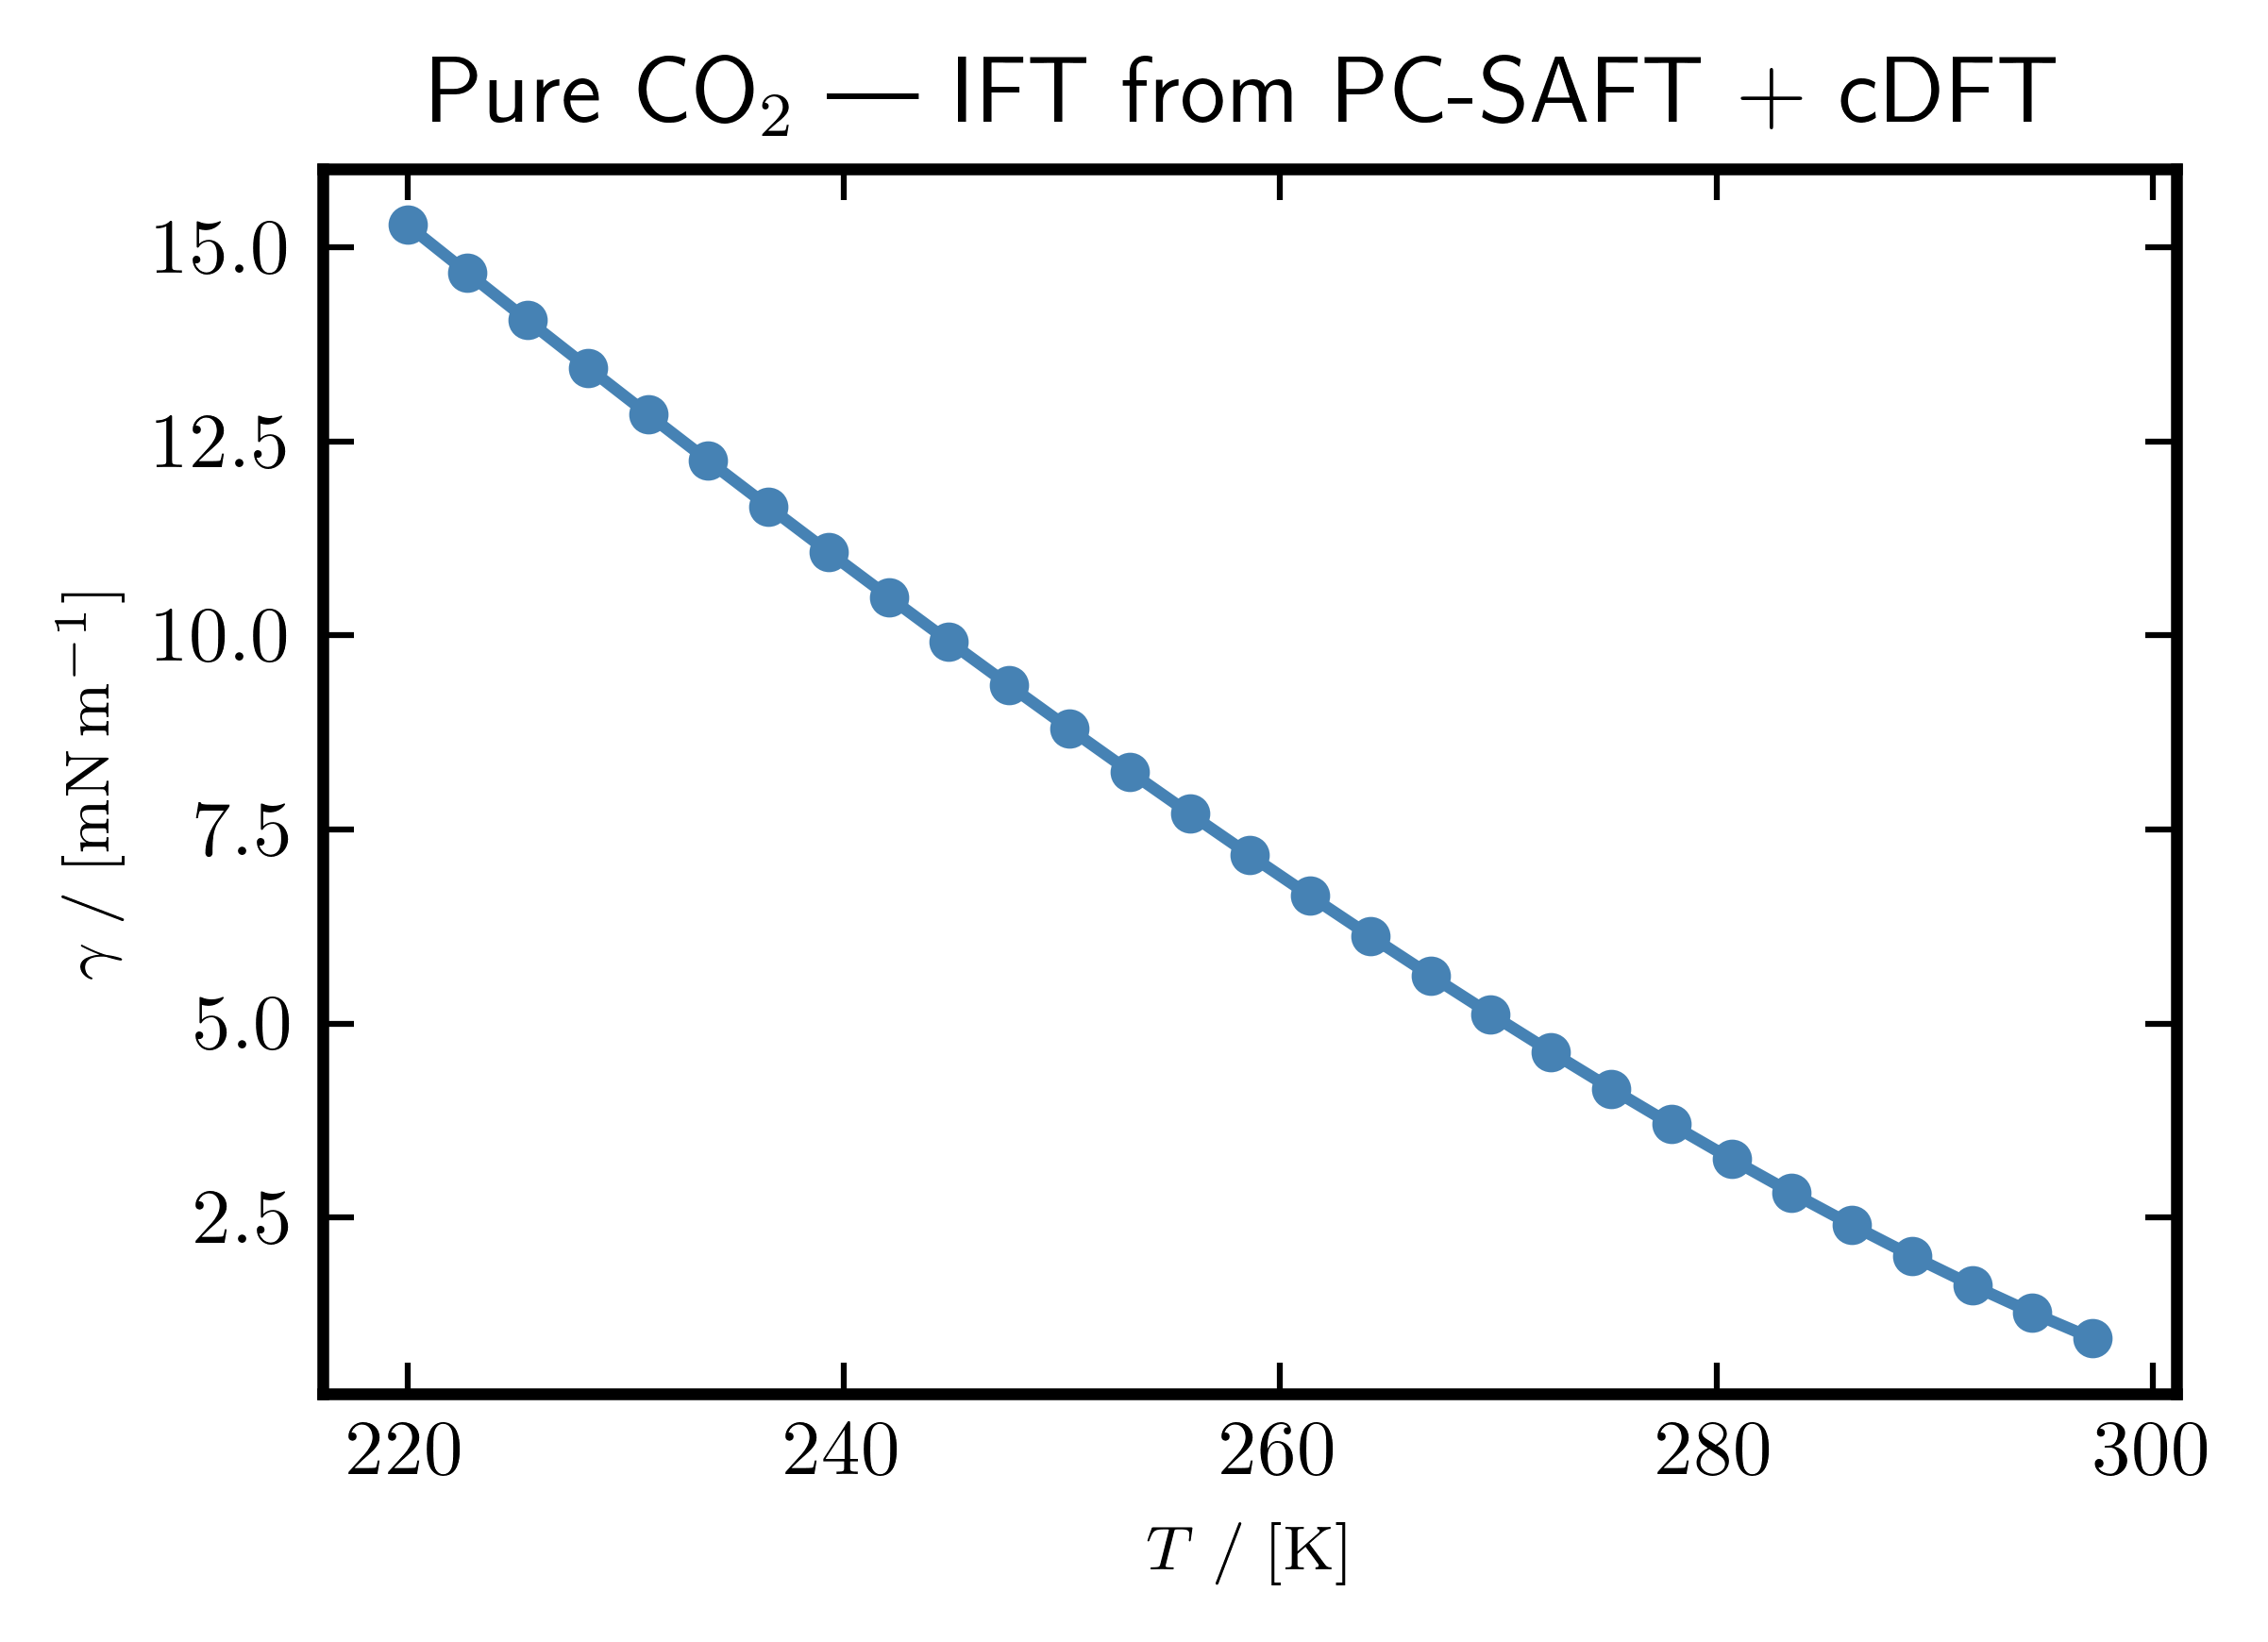

In [3]:
fig, ax = ps.plot_init()
ax.plot(T_list, gamma_list, "o-", markersize=4, color="steelblue")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$")
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$")
ax.set_title(r"Pure CO$_2$ — IFT from PC-SAFT + cDFT")
plt.tight_layout()
plt.show()